# **Visualisasi Data Raster -Small Multiple Maps**


---
**Defani Arman Alfitriansyah**
https://github.com/Defani


# **Instalasi Package**

In [1]:
!pip install geemap
!pip install cartopy
!pip install matplotlib
!pip install earthengine-api

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 108.5 MB/s eta 0:00:00


# **Kode Anaalisis**

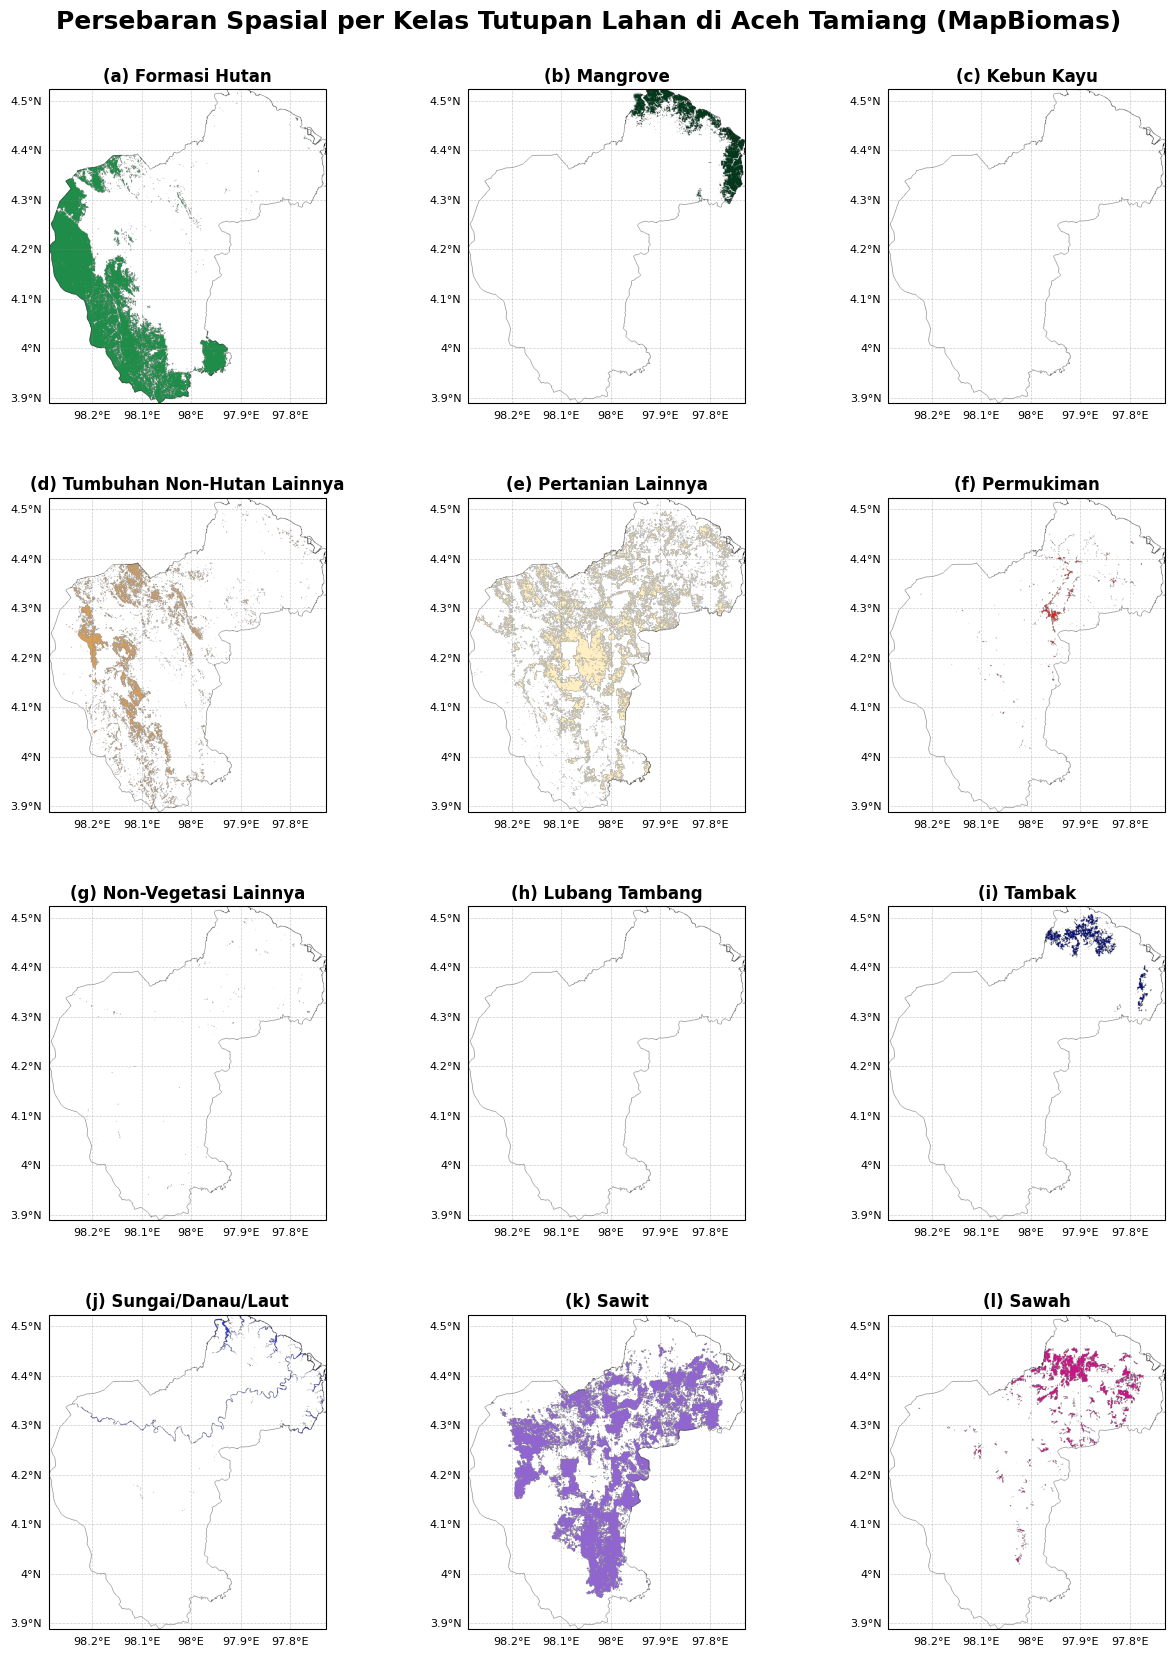

In [5]:
import ee
import geemap.cartoee as cartoee
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import math
from cartopy.mpl.geoaxes import GeoAxes
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ee.Authenticate()
ee.Initialize(project='ee-defaniarman')

batas_wilayah = ee.FeatureCollection("projects/ee-defaniarman/assets/ACEH_TAMIANG")

mb_img = ee.Image('projects/mapbiomas-public/assets/indonesia/lulc/collection4/mapbiomas_indonesia_collection4_coverage_v2')
mb_batas = mb_img.select('classification_2022').clip(batas_wilayah)

batas_outline = ee.Image().byte().paint(featureCollection=batas_wilayah, color=1, width=1)

mapbiomas_legend = [
    {"id": 3, "name": "Formasi Hutan", "color": "#1f8d49"},
    {"id": 5, "name": "Mangrove", "color": "#04381d"},
    {"id": 9, "name": "Kebun Kayu", "color": "#7a5900"},
    {"id": 13, "name": "Tumbuhan Non-Hutan Lainnya", "color": "#d89f5c"},
    {"id": 21, "name": "Pertanian Lainnya", "color": "#ffefc3"},
    {"id": 24, "name": "Permukiman", "color": "#d4271e"},
    {"id": 25, "name": "Non-Vegetasi Lainnya", "color": "#db4d4f"},
    {"id": 30, "name": "Lubang Tambang", "color": "#9c0027"},
    {"id": 31, "name": "Tambak", "color": "#091077"},
    {"id": 33, "name": "Sungai/Danau/Laut", "color": "#2532e4"},
    {"id": 35, "name": "Sawit", "color": "#9065d0"},
    {"id": 40, "name": "Sawah", "color": "#c71585"}
]

bounds = batas_wilayah.geometry().bounds().getInfo()['coordinates'][0]
region_bbox = [bounds[0][0], bounds[0][1], bounds[2][0], bounds[2][1]]

n_classes = len(mapbiomas_legend)
ncols = 3
nrows = math.ceil(n_classes / ncols)

fig = plt.figure(figsize=(15, 5 * nrows))

for i, cls in enumerate(mapbiomas_legend):
    ax = fig.add_subplot(nrows, ncols, i + 1, projection=ccrs.PlateCarree())

    cls_img = mb_batas.updateMask(mb_batas.eq(cls['id']))

    cartoee.add_layer(ax, cls_img, region=region_bbox, vis_params={'min': cls['id'], 'max': cls['id'], 'palette': [cls['color']]})
    cartoee.add_layer(ax, batas_outline, region=region_bbox, vis_params={'palette': ['#000000']})

    gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4, linewidth=0.5)
    gl.top_labels = False
    gl.right_labels = False
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER
    gl.xlabel_style = {'size': 8}
    gl.ylabel_style = {'size': 8}

    label_huruf = chr(97 + i)
    ax.set_title(f"({label_huruf}) {cls['name']}", fontsize=12, fontweight='bold')

plt.suptitle("Persebaran Spasial per Kelas Tutupan Lahan di Aceh Tamiang (MapBiomas)", fontsize=18, fontweight='bold', y=0.92)

plt.subplots_adjust(wspace=0.3, hspace=0.3)
plt.show()

# **Layout Single**

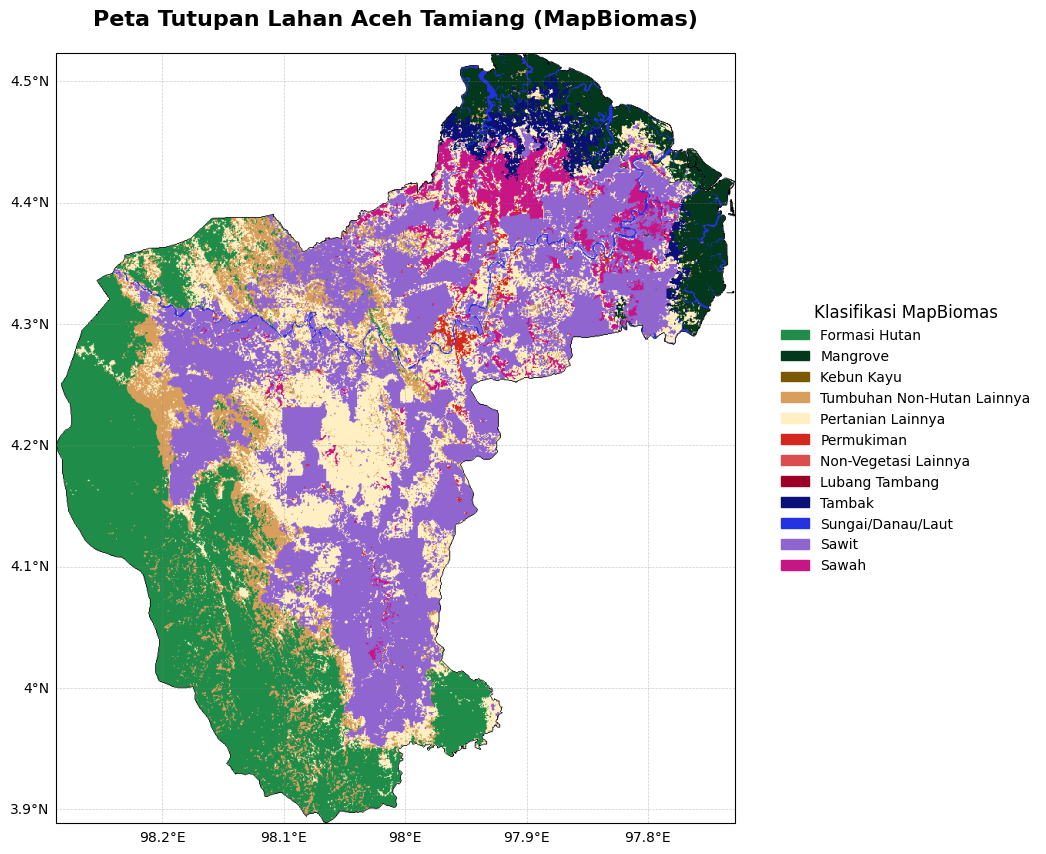

In [6]:

import ee
import geemap.cartoee as cartoee
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import matplotlib.patches as mpatches
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

ee.Authenticate()
ee.Initialize(project='ee-defaniarman')

batas_wilayah = ee.FeatureCollection("projects/ee-defaniarman/assets/ACEH_TAMIANG")

mb_img = ee.Image('projects/mapbiomas-public/assets/indonesia/lulc/collection4/mapbiomas_indonesia_collection4_coverage_v2')
mb_batas = mb_img.select('classification_2024').clip(batas_wilayah)
batas_outline = ee.Image().byte().paint(featureCollection=batas_wilayah, color=1, width=1)

mapbiomas_legend = [
    {"id": 3, "name": "Formasi Hutan", "color": "#1f8d49"},
    {"id": 5, "name": "Mangrove", "color": "#04381d"},
    {"id": 9, "name": "Kebun Kayu", "color": "#7a5900"},
    {"id": 13, "name": "Tumbuhan Non-Hutan Lainnya", "color": "#d89f5c"},
    {"id": 21, "name": "Pertanian Lainnya", "color": "#ffefc3"},
    {"id": 24, "name": "Permukiman", "color": "#d4271e"},
    {"id": 25, "name": "Non-Vegetasi Lainnya", "color": "#db4d4f"},
    {"id": 30, "name": "Lubang Tambang", "color": "#9c0027"},
    {"id": 31, "name": "Tambak", "color": "#091077"},
    {"id": 33, "name": "Sungai/Danau/Laut", "color": "#2532e4"},
    {"id": 35, "name": "Sawit", "color": "#9065d0"},
    {"id": 40, "name": "Sawah", "color": "#c71585"}
]

old_values = [item['id'] for item in mapbiomas_legend]
new_values = list(range(1, len(mapbiomas_legend) + 1))
palette = [item['color'] for item in mapbiomas_legend]

mb_remapped = mb_batas.remap(old_values, new_values)
vis_params = {'min': 1, 'max': len(mapbiomas_legend), 'palette': palette}

bounds = batas_wilayah.geometry().bounds().getInfo()['coordinates'][0]
region_bbox = [bounds[0][0], bounds[0][1], bounds[2][0], bounds[2][1]]

fig = plt.figure(figsize=(12, 10))
ax = cartoee.get_map(mb_remapped, region=region_bbox, vis_params=vis_params, projection=ccrs.PlateCarree())

cartoee.add_layer(ax, batas_outline, region=region_bbox, vis_params={'palette': ['#000000']})

gl = ax.gridlines(draw_labels=True, linestyle='--', color='gray', alpha=0.4, linewidth=0.5)
gl.top_labels = False
gl.right_labels = False
gl.xformatter = LONGITUDE_FORMATTER
gl.yformatter = LATITUDE_FORMATTER
gl.xlabel_style = {'size': 10}
gl.ylabel_style = {'size': 10}

legend_patches = [mpatches.Patch(color=item['color'], label=item['name']) for item in mapbiomas_legend]
ax.legend(handles=legend_patches, title='Klasifikasi MapBiomas', loc='center left', bbox_to_anchor=(1.05, 0.5), fontsize=10, title_fontsize=12, frameon=False)

ax.set_title("Peta Tutupan Lahan Aceh Tamiang (MapBiomas)", fontsize=16, fontweight='bold', pad=20)

plt.show()